Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Load Dataset

In [2]:
df = pd.read_excel("Department Awareness Survey (Responses).xlsx")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


Dataset Informations

In [3]:
df.head()
print("Rows and Columns :", df.shape)
print(df.isnull().sum())
df = df.dropna()
print(df.shape)
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Rows and Columns : (54, 15)
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are you

Converting required columns to numeric 

In [4]:
df['your GPA of last semester'] = pd.to_numeric(
    df['your GPA of last semester'],
    errors='coerce'
)

df['your CIA % of last semester '] = pd.to_numeric(
    df['your CIA % of last semester '],
    errors='coerce'
)

df['Your maximum attendance % till last semester'] = pd.to_numeric(
    df['Your maximum attendance % till last semester'],
    errors='coerce'
)

df = df.dropna()

Summary

In [5]:
df.describe()

,Timestamp,Rate your contribution towards extra curricular activities,Rate your technical competencies,your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
count,46,46.000000,46.000000,46.000000,46.000000,46.000000
mean,2026-06-22 08:53:44.175543,3.630435,3.456522,58.326763,5.623913,79.100402
min,2026-06-22 08:51:00.666000,2.000000,1.000000,0.630000,2.900000,0.870000
25%,2026-06-22 08:52:35.795250,3.000000,3.000000,65.002500,3.400000,86.250000
50%,2026-06-22 08:53:30.697500,4.000000,3.000000,70.000000,3.505000,92.000000
75%,2026-06-22 08:54:33.959250,4.000000,4.000000,78.000000,3.730000,96.750000
max,2026-06-22 08:57:57.108000,5.000000,5.000000,89.000000,90.000000,100.000000
std,NaN,0.951226,0.751488,30.939425,12.769951,33.757066


Experiment 1
CIA Percentage

In [6]:
#Independent and Dependent Variables

X = df[['your CIA % of last semester ']]

y = df['your GPA of last semester']

In [7]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.07]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['your CIA % of last semester ']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.658
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [9]:
# Slope and Intercept
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 0.06867502407800606
Intercept: 1.657904973456076


In [10]:
# Prediction
y_pred = model.predict(X_test)

print(y_pred)

[1.93260507 1.71078474 7.1519069  7.56395704 6.46515666 7.01455685
 6.46515666 1.70673978 6.46515666 1.89483381]


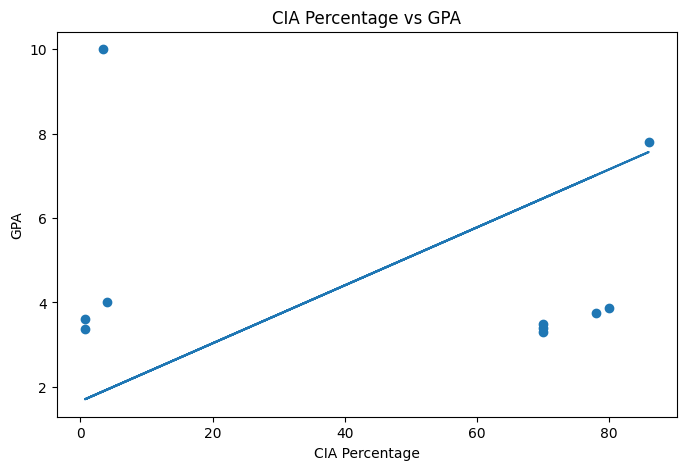

In [11]:
# Visualisation
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")

plt.title("CIA Percentage vs GPA")

plt.show()

In [12]:
# Calculating Slope Manually
x = X.values.flatten()
y_actual = y.values

x_mean = np.mean(x)
y_mean = np.mean(y_actual)

numerator = np.sum(
    (x - x_mean)*(y_actual - y_mean)
)

denominator = np.sum(
    (x - x_mean)**2
)

m = numerator/denominator

b = y_mean - (m*x_mean)

print("Manual Slope =", m)
print("Manual Intercept =", b)

Manual Slope = 0.04549568813574868
Manual Intercept = 2.970296822084463


In [13]:
# Manual Regression Equation
print(f"GPA = {m:.4f} * CIA + {b:.4f}")

GPA = 0.0455 * CIA + 2.9703


In [14]:
# Manual Prediction
manual_predictions = m * X_test.values.flatten() + b

print(manual_predictions)

[3.15227957 3.0053285  6.60995187 6.882926   6.15499499 6.5189605
 6.15499499 3.00264881 6.15499499 3.12725695]


In [15]:
# Comparison 
comparison = pd.DataFrame({
    "Sklearn Prediction": y_pred,
    "Manual Prediction": manual_predictions
})

comparison["Difference"] = abs(
    comparison["Sklearn Prediction"]
    - comparison["Manual Prediction"]
)

comparison.head(10)

,Sklearn Prediction,Manual Prediction,Difference
0,1.932605,3.152280,1.219675
1,1.710785,3.005329,1.294544
2,7.151907,6.609952,0.541955
3,7.563957,6.882926,0.681031
4,6.465157,6.154995,0.310162
5,7.014557,6.518960,0.495596
6,6.465157,6.154995,0.310162
7,1.706740,3.002649,1.295909
8,6.465157,6.154995,0.310162
9,1.894834,3.127257,1.232423


In [16]:
# Saving the parameters
parameters = {
    "slope": slope,
    "intercept": intercept
}

with open(
    "linear_regression_weights.pkl",
    "wb"
) as file:
    pickle.dump(parameters, file)

print("Parameters Saved Successfully")

Parameters Saved Successfully


In [17]:
# Loading Parameters
with open(
    "linear_regression_weights.pkl",
    "rb"
) as file:
    
    loaded_parameters = pickle.load(file)

print(loaded_parameters)

{'slope': 0.06867502407800606, 'intercept': 1.657904973456076}


In [18]:
# Predicting using loaded parameters
loaded_slope = loaded_parameters["slope"]
loaded_intercept = loaded_parameters["intercept"]

sample_cia = 85

predicted_gpa = (
    loaded_slope * sample_cia
    + loaded_intercept
)

print(
    "Predicted GPA:",
    predicted_gpa
)

Predicted GPA: 7.4952820200865915


Experiment 2 
Attendance Percentage → GPA

In [19]:
# Selecting variables
X = df[['Your maximum attendance % till last semester']]

y = df['your GPA of last semester']

In [20]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Training the model
attendance_model = LinearRegression()

attendance_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Your maximum attendance % till last semester']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.984
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [22]:
# parameters
print(
    "Slope:",
    attendance_model.coef_[0]
)

print(
    "Intercept:",
    attendance_model.intercept_
)

Slope: 0.011319297583765762
Intercept: 4.984252420000036


In [23]:
# Predictions
attendance_pred = attendance_model.predict(
    X_test
)

print(attendance_pred)

[6.11618218 4.99523214 6.07090499 5.95771201 5.9916699  6.10871144
 5.9916699  4.99492086 6.08222429 6.0029892 ]


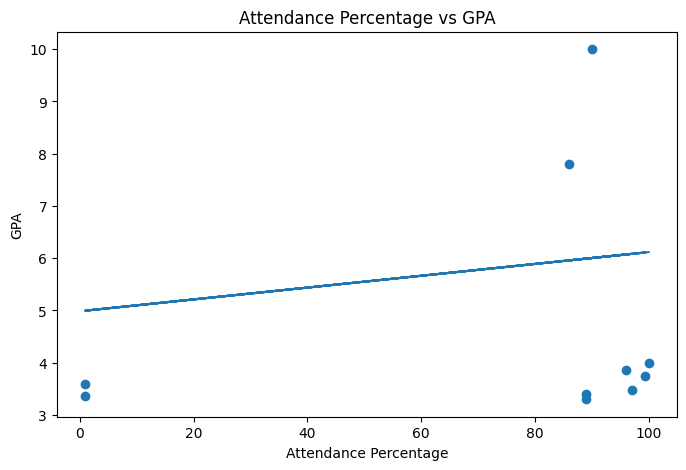

In [24]:
# Graph
plt.figure(figsize=(8,5))

plt.scatter(
    X_test,
    y_test
)

plt.plot(
    X_test,
    attendance_pred
)

plt.xlabel("Attendance Percentage")

plt.ylabel("GPA")

plt.title(
    "Attendance Percentage vs GPA"
)

plt.show()

Observations
1. The dataset was cleaned by removing missing values and duplicate records but we could not find any missing values
2. Used simple linear regression and applied scikit-learn to predict GPA from CIA percentage
3. Used the same regression to compute manually using OLS
4. Slope and intercept from 2 methods was indentical 
5. Model parameters was saved and loaded using pickle